# Pipeline overview

Every comparison ocean-skill draws goes through the same five stages. This notebook
walks through them one at a time, on real data, so each stage's *output* is visible
before the next one runs.

![pipeline](pipeline_diagram.png)

Solid boxes are implemented today; the dashed QC box is designed (a per-variable
QARTOD config in the catalog, applied via `ioos_qc`) but not yet wired in — it's shown
because it is part of the pipeline's shape, not because it does anything yet.

## 0. Setup

Two catalogs, already built and auto-discovered: `GOM_bgc` (ROMS-MARBL output, read as
a virtual zarr / kerchunk reference — no roms-tools needed) and WOA23's nitrate
climatology (an intake-erddap-style OPeNDAP source, cached).

In [1]:
import ocean_skill as osk

NITRATE = "mole_concentration_of_nitrate_in_sea_water"
REFERENCE = "woa23_nitrate_month01"
TEST = "GOM_bgc"

print(osk.describe(REFERENCE))

source: World Ocean Atlas 2023 (1 deg) — annual + monthly climatology:woa23_nitrate_month01
  path: /Users/kthyng/packages/ocean-skill/catalogs/woa.catalog.yaml
  climatology: True
  climatology_period: month01
  depth_coord: depth
  featureType: grid
  featureType_source: declared
  geospatial_lat_max: 89.5
  geospatial_lat_min: -89.5
  geospatial_lon_max: 179.5
  geospatial_lon_min: -179.5
  institution: NOAA NCEI
  lon_convention: -180-180
  nominal_resolution_km: 111
  standard_names: {'n_an': 'moles_of_nitrate_per_unit_mass_in_sea_water'}
  title: WOA23 nitrate (month01, 1 deg)
  variables: ['moles_of_nitrate_per_unit_mass_in_sea_water']
  woa_period_code: 01


/Users/kthyng/packages/ocean-skill/ocean_skill/catalog.py:223: UserWarning: Entry name 'GOM_bgc' in /Users/kthyng/packages/ocean-skill/docs/catalogs/gom.yaml shadows /Users/kthyng/packages/ocean-skill/catalogs/gom_offline.yaml; use 'GOM offline run:GOM_bgc' to disambiguate.
  index = discover()


## 1. Read — catalog entry to a CF-standardized object

`osk.read(name)` opens the intake v2 entry and standardizes it: axes renamed to
CF conventions, variables mapped to CF `standard_name`s, land masked, depth
reconstructed. The *type* is determined by the catalog's `featureType` — gridded
sources come back as an `xarray.Dataset`; point sources (a mooring, an ERDDAP
`tabledap` series) come back as a `pandas.DataFrame`. Same call either way.

In [2]:
ds = osk.read(TEST)
ds

/Users/kthyng/packages/ocean-skill/ocean_skill/catalog.py:160: UserWarning: Entry name 'GOM_bgc' in /Users/kthyng/packages/ocean-skill/docs/catalogs/gom.yaml shadows /Users/kthyng/packages/ocean-skill/catalogs/gom_offline.yaml; use 'GOM offline run:GOM_bgc' to disambiguate.
  index = discover()


<xarray.Dataset> Size: 417MB
Dimensions:                                                        (time: 31,
                                                                    s_rho: 20,
                                                                    eta_rho: 82,
                                                                    xi_rho: 102,
                                                                    s_w: 21,
                                                                    eta_coarse: 42,
                                                                    xi_coarse: 52,
                                                                    xi_u: 101,
                                                                    eta_v: 81)
Coordinates: (12/17)
  * time                                                           (time) datetime64[s] 248B ...
    Cs_r                                                           (s_rho) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    sigma_r                                                        (s_rho) float32 80B dask.array<chunksize=(20,), meta=np.ndarray>
    angle                                                          (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    h                                                              (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    mask_rho                                                       (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    ...                                                             ...
    lat                                                            (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=np.ndarray>
    z_rho                                                          (s_rho, eta_rho, xi_rho) float64 1MB dask.array<chunksize=(20, 82, 102), meta=np.ndarray>
    lat_coarse                                                     (eta_coarse, xi_coarse) float64 17kB dask.array<chunksize=(42, 52), meta=np.ndarray>
    lon_coarse                                                     (eta_coarse, xi_coarse) float64 17kB dask.array<chunksize=(42, 52), meta=np.ndarray>
    lat_u                                                          (eta_rho, xi_u) float64 66kB dask.array<chunksize=(82, 101), meta=np.ndarray>
    lon_u                                                          (eta_rho, xi_u) float64 66kB dask.array<chunksize=(82, 101), meta=np.ndarray>
Dimensions without coordinates: s_rho, eta_rho, xi_rho, s_w, eta_coarse,
                                xi_coarse, xi_u, eta_v
Data variables: (12/21)
    sea_water_alkalinity_expressed_as_mole_equivalent              (time, s_rho, eta_rho, xi_rho) float64 41MB dask.array<chunksize=(1, 20, 82, 102), meta=np.ndarray>
    Cs_w                                                           (s_w) float32 84B dask.array<chunksize=(21,), meta=np.ndarray>
    mole_concentration_of_dissolved_inorganic_carbon_in_sea_water  (time, s_rho, eta_rho, xi_rho) float64 41MB dask.array<chunksize=(1, 20, 82, 102), meta=np.ndarray>
    mole_concentration_of_dissolved_iron_in_sea_water              (time, s_rho, eta_rho, xi_rho) float64 41MB dask.array<chunksize=(1, 20, 82, 102), meta=np.ndarray>
    mole_concentration_of_ammonium_in_sea_water                    (time, s_rho, eta_rho, xi_rho) float64 41MB dask.array<chunksize=(1, 20, 82, 102), meta=np.ndarray>
    mole_concentration_of_nitrate_in_sea_water                     (time, s_rho, eta_rho, xi_rho) float64 41MB dask.array<chunksize=(1, 20, 82, 102), meta=np.ndarray>
    ...                                                             ...
    ocean_time                                                     (time) float64 248B dask.array<chunksize=(31,), meta=np.ndarray>
    pm                                                             (eta_rho, xi_rho) float64 67kB dask.array<chunksize=(82, 102), meta=n

Notice `sea_water_potential_temperature`/`NO3`'s CF name, `lon`/`lat`/`z_rho` as
coordinates (not data variables), and land already masked to NaN — none of that is
visible in the raw model output; `read` did it.

## 2. Select / operator — reduce to one comparable field

For this pair that means: pick the variable (resolving whichever of the per-volume /
per-mass CF spelling the source actually uses — WOA and MARBL disagree), reduce to one
time (a mean, here), and pick a depth. `"surface"` (the default) means the model's own
top s-level; a literal `0` is a different, real request — interpolated like any other
depth, which can legitimately come back all-NaN if the top cell centre already sits
below 0 m.

This stage is currently inline in `Comparison`/`compare()` rather than its own
`operators.py` module (that module is a designed-but-stub seam for a fuller
select/aggregate grammar — climatology groupby, vertical integrals, frequency-of-times
fan-out).

In [3]:
c = osk.Comparison(aggregate={"time": "mean"}, reference=REFERENCE, test=TEST, variable=NITRATE)
# nothing has run yet -- align()/plot()/metrics() trigger it lazily
c

<Comparison nitrate_in_sea_water GOM_bgc vs woa23_nitrate_month01 @ surface>

## 3. Align — bring test onto reference

`align()` regrids the model (test) onto the reference's grid — conservative-normed by
default, with a coverage mask so cells with too little overlap don't produce a
confident-looking but meaningless value. Longitude convention is harmonized first
(ROMS' 0-360 vs the reference's ±180) — skipping that silently produces garbage for
any domain crossing the dateline.

In [4]:
aligned = c.align()
aligned

/Users/kthyng/packages/ocean-skill/ocean_skill/catalog.py:160: UserWarning: Entry name 'GOM_bgc' in /Users/kthyng/packages/ocean-skill/docs/catalogs/gom.yaml shadows /Users/kthyng/packages/ocean-skill/catalogs/gom_offline.yaml; use 'GOM offline run:GOM_bgc' to disambiguate.
  index = discover()


/Users/kthyng/packages/ocean-skill/ocean_skill/catalog.py:160: UserWarning: Entry name 'GOM_bgc' in /Users/kthyng/packages/ocean-skill/docs/catalogs/gom.yaml shadows /Users/kthyng/packages/ocean-skill/catalogs/gom_offline.yaml; use 'GOM offline run:GOM_bgc' to disambiguate.
  index = discover()


<xarray.Dataset> Size: 12kB
Dimensions:     (lon: 24, lat: 17)
Coordinates:
  * lon         (lon) float32 96B -100.5 -99.5 -98.5 -97.5 ... -79.5 -78.5 -77.5
  * lat         (lat) float32 68B 15.5 16.5 17.5 18.5 ... 28.5 29.5 30.5 31.5
    Cs_r        float32 4B dask.array<chunksize=(), meta=np.ndarray>
    sigma_r     float32 4B dask.array<chunksize=(), meta=np.ndarray>
    depth       float32 4B 0.0
    time        float32 4B 336.5
Data variables:
    test        (lat, lon) float64 3kB dask.array<chunksize=(17, 24), meta=np.ndarray>
    reference   (lat, lon) float32 2kB dask.array<chunksize=(17, 24), meta=np.ndarray>
    difference  (lat, lon) float64 3kB dask.array<chunksize=(17, 24), meta=np.ndarray>
    coverage    (lat, lon) float64 3kB dask.array<chunksize=(17, 24), meta=np.ndarray>
Attributes:
    regrid_method:   conservative_normed
    lon_convention:  -180-180
    min_coverage:    0.5

## 4. Metrics — one record per comparison

`xskillscore`, area-weighted by cos(latitude), only over cells finite in *both*
members. Below `min_samples` (default 30) it warns rather than reporting a
confident-looking number from a handful of cells.

In [5]:
c.metrics()

{'bias': 0.20704069936225447,
 'rmse': 1.4916084282093176,
 'mae': 1.078771753454654,
 'corr': 0.5319143624449604,
 'sigma_ratio': 0.37101927905823445,
 'std_test': 0.6358368565339977,
 'std_reference': 1.7137569189071655,
 'crmsd': 1.4771695406799652,
 'mean_test': 1.2077115747293472,
 'mean_reference': 1.0006710290908813,
 'n': 175,
 'weighted': True,
 'variable': 'mole_concentration_of_nitrate_in_sea_water',
 'test': 'GOM_bgc',
 'reference': 'woa23_nitrate_month01',
 'depth': 'surface',
 'obs_depth': 0.0,
 'regrid': 'conservative_normed'}

## 5. Plot — a spec, drawn by a swappable renderer

`plot()` builds a backend-agnostic `PlotSpec` and hands it to the renderer registry.
The model-domain box is drawn automatically from the test source's own catalog extent
— no argument needed, matching Abigale Wyatt's original `Obs_comparisons.ipynb` style.

/Users/kthyng/packages/ocean-skill/ocean_skill/catalog.py:160: UserWarning: Entry name 'GOM_bgc' in /Users/kthyng/packages/ocean-skill/docs/catalogs/gom.yaml shadows /Users/kthyng/packages/ocean-skill/catalogs/gom_offline.yaml; use 'GOM offline run:GOM_bgc' to disambiguate.
  index = discover()


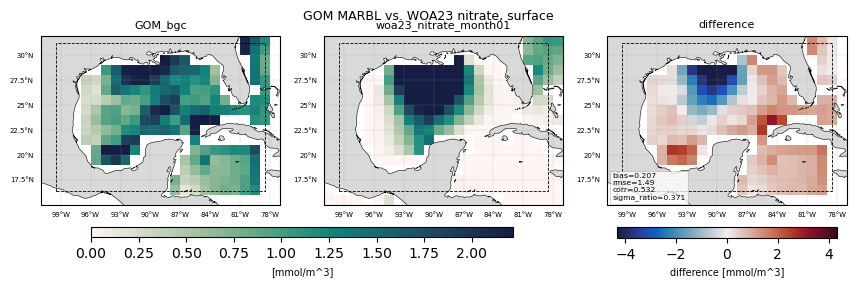

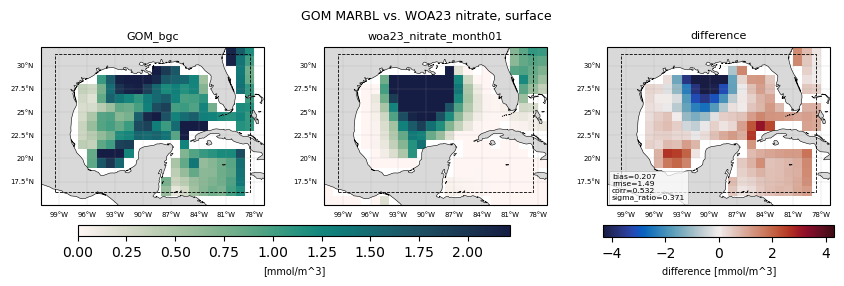

In [6]:
c.plot(title="GOM MARBL vs. WOA23 nitrate, surface")

### Same spec, different renderer

Swapping `renderer="holoviews"` draws the *same* spec interactively — no other change.
See `interactive.ipynb` for more on this switch (and why Taylor diagrams stay static).

In [ ]:
c.plot(renderer="holoviews", title="GOM MARBL vs. WOA23 nitrate, surface")

## Writing outputs

Metrics go to a tidy CSV/TXT alongside the figure — the file is the durable record;
the plot's corner box is only the headline numbers.

In [8]:
from ocean_skill import metrics as _metrics

_metrics.write([c.metrics()], "/tmp/ocean_skill_demo", stem="nitrate_surface")

PosixPath('/tmp/ocean_skill_demo/metrics/nitrate_surface.csv')

## Where to go next

- **`getting_started.ipynb`** — the full comparison API: multiple variables/depths at
  once, `compare()`'s reference×test fan-out, Taylor and Target summary diagrams.
- **`interactive.ipynb`** — the static⇄interactive renderer switch in more depth.
- **`intake_v2_reference.md`** — the catalog format, if you're adding a new source.